# Telecom Data Anonymisation Visualizer
This notebook allows you to visually inspect the results of the M2 anonymisation pipeline.
We will load the safe `outputs/anonymised.parquet` dataset and look at how the data was transformed to preserve privacy.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_theme(style="whitegrid")

# Load the safe anonymised dataset
df_anon = pd.read_parquet('outputs/anonymised.parquet')
print(f"Loaded {len(df_anon):,} rows.")
df_anon.head()

Loaded 1,097,484 rows.


,time_start,tp_dl_avg,tp_ul_avg,tp_dl_filtered_avg,cont_rtt_radio_avg,cont_rtt_internet_avg,initial_rtt_radio_avg,tcp_retrans_byte_ratio_downlink_avg,tcp_retrans_byte_ratio_uplink_avg,http_response_time_avg,...,data_GB_sum,im_video_GB_sum,im_audio_GB_sum,tethering_data_GB_dl_sum,radio_access_type,province,application_category,enb,tac,pseudonym_id
0,2027-04-30 16:00:00,0.00000,0.00003,NaN,NaN,NaN,NaN,NaN,0.00000,0.0,...,0.00001,0.0,0.0,0.0,2G,Uusimaa,P2P,CELL_b8bcfb30,10000000,05ba924f-4de143a4
1,2027-04-30 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.00000,0.00000,0.0,...,0.00045,0.0,0.0,0.0,5G,Etelä-Pohjanmaa,Remote access,CELL_154f3bb8,10000000,ca9fb6d9-294fcc9a
2,2027-04-30 16:00:00,0.49352,0.07487,NaN,172.30437,128.19560,17.99318,0.03737,0.01847,0.0,...,0.00239,0.0,0.0,0.0,5G,Uusimaa,AI,CELL_19de3952,10000000,bd479015-7dbc98a3
3,2027-04-30 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.00000,0.00000,0.0,...,0.00002,0.0,0.0,0.0,5G,Uusimaa,Chat,CELL_f08bc272,10000000,7ca70b54-4c889d40
4,2027-04-30 16:00:00,0.08682,0.05236,NaN,59.35648,88.32307,18.15115,0.00000,0.00000,0.0,...,0.00004,0.0,0.0,0.0,4G,Uusimaa,AI,CELL_833b3433,10000000,382b0c55-9ba8ace3


## 1. Top-Coding of Sensitive Attributes
Extreme outliers in usage volumes (like video streaming or tethering) can make a user uniquely identifiable (the R3 risk). Our pipeline tops-codes these values at the 99th percentile.
Let's visualize the distribution.

Number of video users: 2234


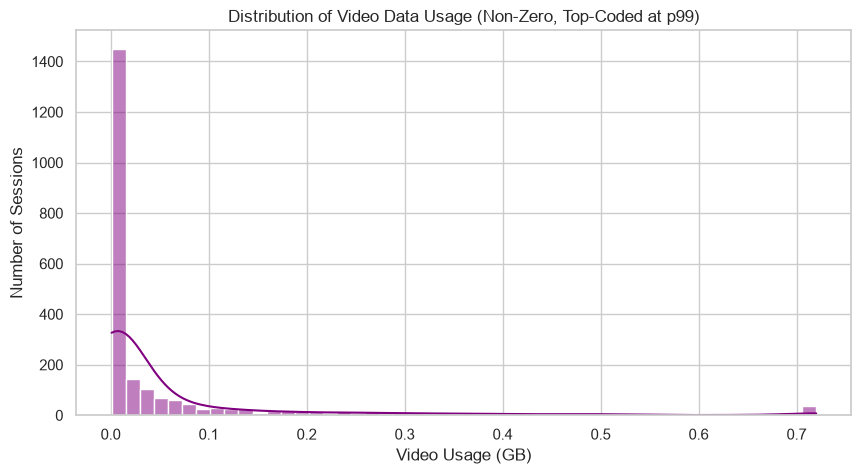

In [14]:
plt.figure(figsize=(10, 5))
# Filter out 0s to see the actual distribution of video watchers
video_users = df_anon[df_anon['im_video_GB_sum'] > 0]
print("Number of video users: " + str(len(video_users)))
sns.histplot(data=video_users, x='im_video_GB_sum', bins=50, kde=True, color='purple')
plt.title('Distribution of Video Data Usage (Non-Zero, Top-Coded at p99)')
plt.xlabel('Video Usage (GB)')
plt.ylabel('Number of Sessions')
plt.show()

## 2. Generalization of Cells (k-Anonymity)
To ensure no one can be tracked to a lonely cell tower, any cell with fewer than `k=5` users was grouped into the `OTHER_ENB` bucket.
Let's see how many sessions were mapped to `OTHER_ENB` compared to the top 10 most popular cells.

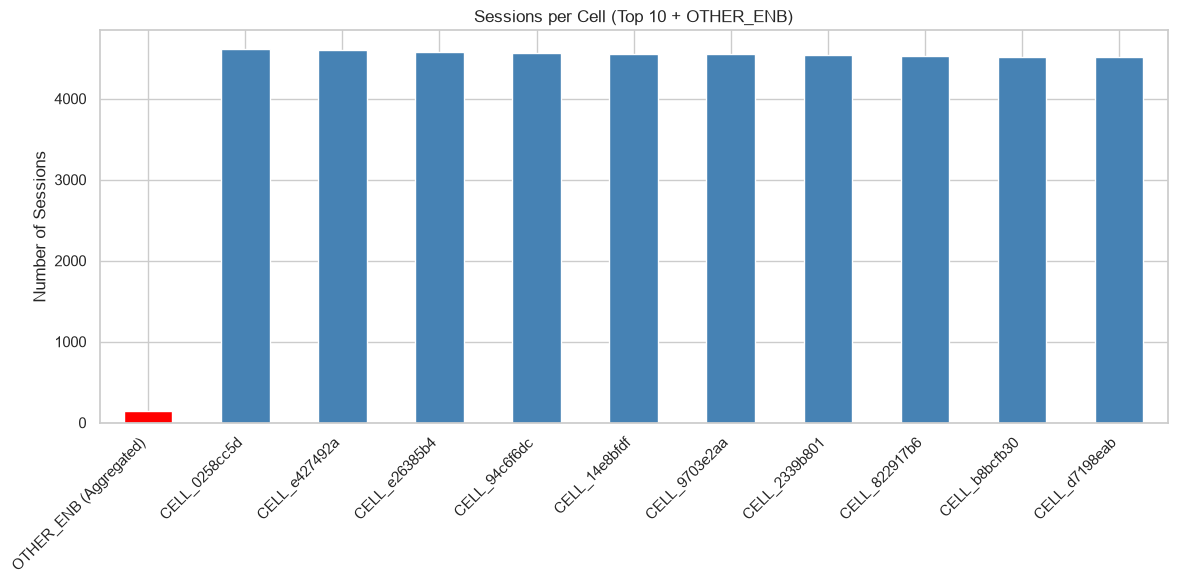

In [15]:
# Count sessions per cell
cell_counts = df_anon['enb'].value_counts()

# Separate 'OTHER_ENB' from the rest
other_count = cell_counts.get('OTHER_ENB', 0)
top_cells = cell_counts[cell_counts.index != 'OTHER_ENB'].head(10)

plot_data = pd.concat([pd.Series({'OTHER_ENB (Aggregated)': other_count}), top_cells])

plt.figure(figsize=(12, 6))
plot_data.plot(kind='bar', color=['red'] + ['steelblue']*10)
plt.title('Sessions per Cell (Top 10 + OTHER_ENB)')
plt.ylabel('Number of Sessions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Transformation Log
Finally, let's review the exact transformation rules that were applied to generate this file.

In [16]:
with open('outputs/transform_log.json', 'r') as f:
    log = json.load(f)
    
print(json.dumps(log, indent=2))

{
  "linkage": {
    "linkage_window": "daily",
    "dropped_identifiers": [
      "msisdn",
      "imsi",
      "imei"
    ]
  },
  "generalization": {
    "k_threshold": 5,
    "actions": {
      "time_start": "floored to hour",
      "enb": "grouped 46 rare values into OTHER and hashed remaining to short strings",
      "tac": "grouped 0 rare values into OTHER",
      "im_video_GB_sum": "top-coded at non-zero p99 (0.720) and rounded to 3 decimals",
      "im_audio_GB_sum": "top-coded at non-zero p99 (0.097) and rounded to 3 decimals",
      "tethering_data_GB_dl_sum": "top-coded at non-zero p99 (0.794) and rounded to 3 decimals"
    }
  },
  "k_anonymity": {
    "qi_set": [
      "time_start",
      "radio_access_type",
      "province",
      "enb",
      "tac"
    ],
    "suppressed_rows": 1856,
    "pct_suppressed": 0.00168829,
    "k_threshold": 5
  },
  "final_rows": 1097484
}
